<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/Examen_Transversal_Mineria_Datos_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen Transversal - BIY7121 Mineria de Datos
## Caso IBM HR Analytics: Prediccion y Analisis de Attrition

**Integrantes:** Catalina Nunez Yanez

**Institucion:** Instituto Profesional DuocUC - Sede Puerto Montt

Este notebook contiene el desarrollo completo del proyecto: preparacion de datos, analisis exploratorio, 3 modelos de aprendizaje supervisado, 3 modelos de aprendizaje no supervisado, evaluacion de resultados y descubrimiento de patrones.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, precision_score,
                              recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carga y Preparacion de Datos

Se carga el dataset IBM HR Analytics (1,470 empleados, 35 variables) y se revisa su calidad.

In [ ]:
df_raw = pd.read_csv('IBM_HR_Analytics_Employee.csv')
print("Dimensiones originales:", df_raw.shape)
print("Valores nulos:", df_raw.isnull().sum().sum())
print("Filas duplicadas:", df_raw.duplicated().sum())
df_raw.head()

Dimensiones originales: (1470, 35)
Valores nulos: 0
Filas duplicadas: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 1.1 Limpieza: eliminacion de variables constantes

`EmployeeCount`, `Over18` y `StandardHours` tienen un unico valor para todos los registros, por lo que no aportan poder predictivo. `EmployeeNumber` es solo un identificador.

In [ ]:
df = df_raw.copy()
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Columnas constantes eliminadas:", const_cols)
df.drop(columns=const_cols, inplace=True)
df.drop(columns=['EmployeeNumber'], inplace=True)

df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df_eda = df.copy()
print("Dimensiones tras limpieza:", df.shape)

Columnas constantes eliminadas: ['EmployeeCount', 'Over18', 'StandardHours']
Dimensiones tras limpieza: (1470, 32)


### 1.2 Encoding de variables categoricas

Se aplica Label Encoding a las variables categoricas para que puedan ser utilizadas por los algoritmos.

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Attrition']
print("Variables categoricas codificadas:", cat_cols)

label_encoders = {}
df_enc = df.copy()
for c in cat_cols:
    le = LabelEncoder()
    df_enc[c] = le.fit_transform(df_enc[c])
    label_encoders[c] = le

df_enc.drop(columns=['Attrition'], inplace=True)
df_enc.head()

Variables categoricas codificadas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


/tmp/ipykernel_633/988675673.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag
0,41,2,1102,2,1,2,1,2,0,94,...,1,0,8,0,1,6,4,0,5,1
1,49,1,279,1,8,1,1,3,1,61,...,4,1,10,3,3,10,7,1,7,0
2,37,2,1373,1,2,2,4,4,1,92,...,2,0,7,3,3,0,0,0,0,1
3,33,1,1392,1,3,4,1,4,0,56,...,3,0,8,3,3,8,7,3,0,0
4,27,2,591,1,2,1,3,1,1,40,...,4,1,6,3,3,2,2,2,2,0


## 2. Analisis Exploratorio de Datos (EDA) - Prueba de Hipotesis

Se evaluan las 3 hipotesis del caso de estudio:
- **H1 (Sobrecarga laboral):** OverTime vs Attrition
- **H2 (Compensacion y antiguedad):** MonthlyIncome vs Attrition
- **H3 (Equilibrio vida-trabajo):** BusinessTravel y DistanceFromHome vs Attrition

In [ ]:
attrition_rate = df_eda['Attrition_Flag'].mean()
print(f"Tasa de attrition global: {attrition_rate:.2%}")

h1 = df_eda.groupby('OverTime')['Attrition_Flag'].mean()
h2 = df_eda.groupby('Attrition')['MonthlyIncome'].median()
h3a = df_eda.groupby('BusinessTravel')['Attrition_Flag'].mean()
h3b = df_eda.groupby('Attrition')['DistanceFromHome'].mean()
js = df_eda.groupby('JobSatisfaction')['Attrition_Flag'].mean()

print("H1 - Attrition por OverTime:\n", h1, "\n")
print("H2 - Mediana MonthlyIncome por Attrition:\n", h2, "\n")
print("H3a - Attrition por BusinessTravel:\n", h3a, "\n")
print("H3b - Distancia promedio al hogar por Attrition:\n", h3b, "\n")
print("Attrition por JobSatisfaction:\n", js)

Tasa de attrition global: 16.12%
H1 - Attrition por OverTime:
 OverTime
No     0.104364
Yes    0.305288
Name: Attrition_Flag, dtype: float64 

H2 - Mediana MonthlyIncome por Attrition:
 Attrition
No     5204.0
Yes    3202.0
Name: MonthlyIncome, dtype: float64 

H3a - Attrition por BusinessTravel:
 BusinessTravel
Non-Travel           0.080000
Travel_Frequently    0.249097
Travel_Rarely        0.149569
Name: Attrition_Flag, dtype: float64 

H3b - Distancia promedio al hogar por Attrition:
 Attrition
No      8.915653
Yes    10.632911
Name: DistanceFromHome, dtype: float64 

Attrition por JobSatisfaction:
 JobSatisfaction
1    0.228374
2    0.164286
3    0.165158
4    0.113290
Name: Attrition_Flag, dtype: float64


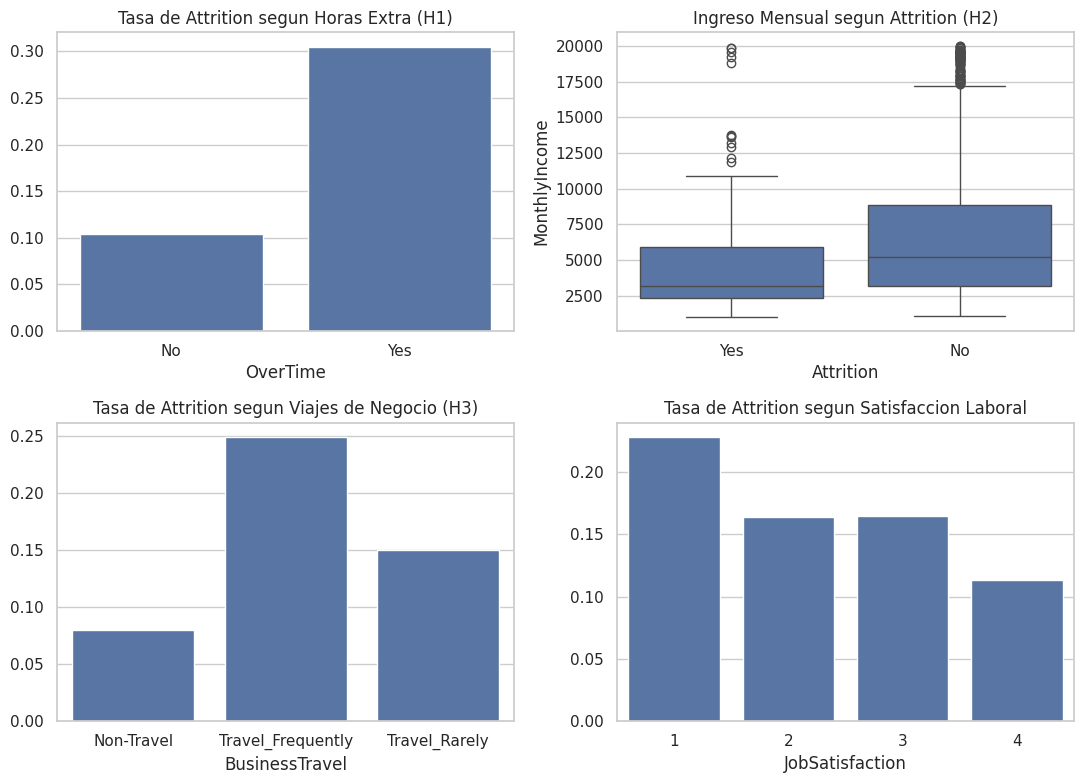

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.barplot(x=h1.index, y=h1.values, ax=axes[0,0])
axes[0,0].set_title('Tasa de Attrition segun Horas Extra (H1)')
sns.boxplot(data=df_eda, x='Attrition', y='MonthlyIncome', ax=axes[0,1])
axes[0,1].set_title('Ingreso Mensual segun Attrition (H2)')
sns.barplot(x=h3a.index, y=h3a.values, ax=axes[1,0])
axes[1,0].set_title('Tasa de Attrition segun Viajes de Negocio (H3)')
sns.barplot(x=js.index, y=js.values, ax=axes[1,1])
axes[1,1].set_title('Tasa de Attrition segun Satisfaccion Laboral')
plt.tight_layout()
plt.show()

### Perfil demografico del empleado desertor

In [ ]:
perfil_edad = df_eda.groupby('Attrition')['Age'].mean()
perfil_civil = df_eda[df_eda.Attrition == 'Yes']['MaritalStatus'].value_counts(normalize=True)
perfil_rol = df_eda[df_eda.Attrition == 'Yes']['JobRole'].value_counts(normalize=True).head(3)

print("Edad promedio por Attrition:\n", perfil_edad, "\n")
print("Estado civil de desertores (%):\n", perfil_civil, "\n")
print("Top 3 roles con mas desercion:\n", perfil_rol)

Edad promedio por Attrition:
 Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64 

Estado civil de desertores (%):
 MaritalStatus
Single      0.506329
Married     0.354430
Divorced    0.139241
Name: proportion, dtype: float64 

Top 3 roles con mas desercion:
 JobRole
Laboratory Technician    0.261603
Sales Executive          0.240506
Research Scientist       0.198312
Name: proportion, dtype: float64


## 3. Aplicacion de Tecnicas de Mineria de Datos

### 3.1 Modelos de Aprendizaje Supervisado (Clasificacion)

Se entrenan 3 modelos para predecir `Attrition`: Regresion Logistica, Random Forest y Gradient Boosting. Dado que la clase minoritaria (Attrition=Yes) representa solo ~16% de los datos, se aplica SMOTE sobre el set de entrenamiento para balancear las clases.

In [ ]:
X = df_enc.drop(columns=['Attrition_Flag'])
y = df_enc['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)
print("Distribucion original train:", y_train.value_counts().to_dict())
print("Distribucion balanceada (SMOTE):", pd.Series(y_train_bal).value_counts().to_dict())

Distribucion original train: {0: 924, 1: 178}
Distribucion balanceada (SMOTE): {0: 924, 1: 924}


In [ ]:
modelos_sup = {
    'Regresion Logistica': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42),
}

resultados_sup = []
roc_data = {}
conf_matrices = {}

for nombre, modelo in modelos_sup.items():
    modelo.fit(X_train_bal, y_train_bal)
    y_pred = modelo.predict(X_test_sc)
    y_proba = modelo.predict_proba(X_test_sc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    resultados_sup.append({'Modelo': nombre, 'Accuracy': acc, 'Precision': prec,
                            'Recall': rec, 'F1-Score': f1, 'AUC-ROC': auc})
    conf_matrices[nombre] = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[nombre] = (fpr, tpr, auc)

    print(f"--- {nombre} ---")
    print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

df_resultados_sup = pd.DataFrame(resultados_sup).sort_values('Recall', ascending=False)
df_resultados_sup

--- Regresion Logistica ---
              precision    recall  f1-score   support

No Attrition       0.93      0.79      0.85       309
   Attrition       0.38      0.68      0.48        59

    accuracy                           0.77       368
   macro avg       0.65      0.73      0.67       368
weighted avg       0.84      0.77      0.79       368



--- Random Forest ---
              precision    recall  f1-score   support

No Attrition       0.88      0.94      0.91       309
   Attrition       0.54      0.34      0.42        59

    accuracy                           0.85       368
   macro avg       0.71      0.64      0.66       368
weighted avg       0.83      0.85      0.83       368



--- Gradient Boosting ---
              precision    recall  f1-score   support

No Attrition       0.89      0.96      0.92       309
   Attrition       0.64      0.39      0.48        59

    accuracy                           0.87       368
   macro avg       0.77      0.67      0.70       368
weighted avg       0.85      0.87      0.85       368



,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Regresion Logistica,0.769022,0.377358,0.677966,0.484848,0.800450
2,Gradient Boosting,0.866848,0.638889,0.389831,0.484211,0.803138
1,Random Forest,0.847826,0.540541,0.338983,0.416667,0.778948


### 3.2 Evaluacion de Modelos: Matrices de Confusion y Curvas ROC

Para IBM, el costo de **no detectar** a un empleado que va a renunciar (falso negativo) es mayor que el costo de intervenir preventivamente a alguien que en realidad se habria quedado (falso positivo). Por eso el **Recall** es la metrica mas critica para elegir el modelo final, sin descuidar el F1-Score como balance general.

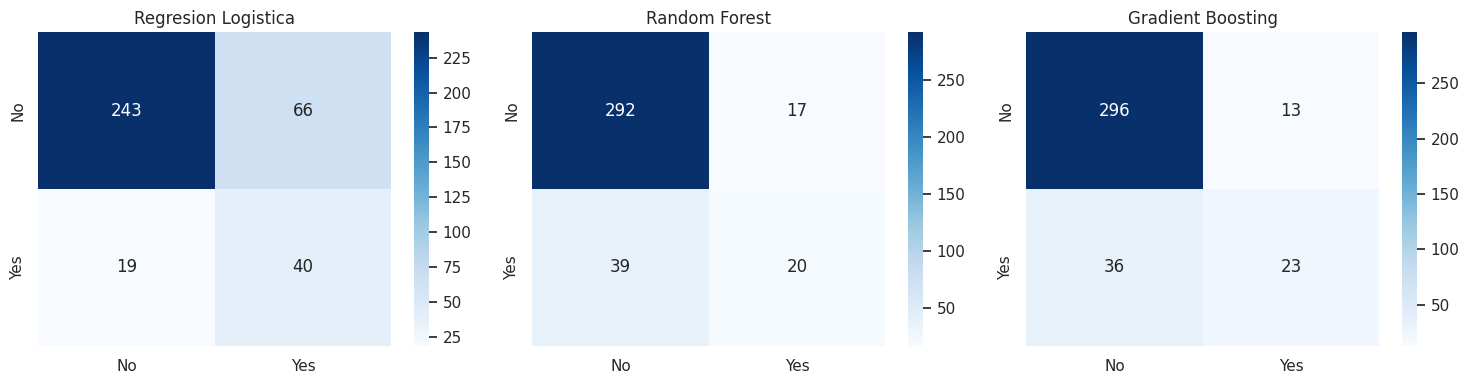

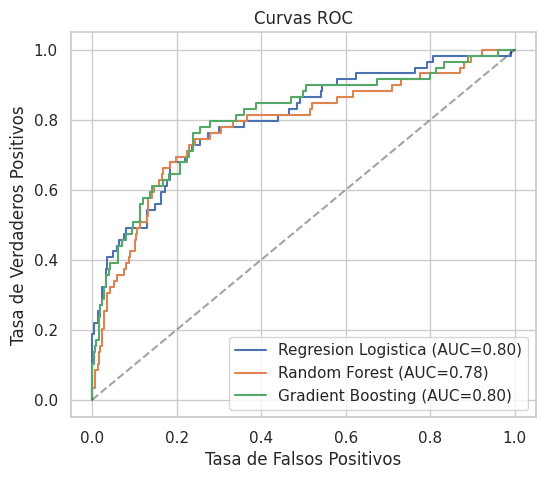

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
for nombre, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.2f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('Tasa de Falsos Positivos'); plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC'); plt.legend()
plt.show()

### 3.3 Importancia de Variables (Random Forest)

Permite identificar que variables aportan mas al modelo predictivo -> insumo directo para el descubrimiento de patrones.

In [ ]:
rf = modelos_sup['Random Forest']
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importancias.head(10)

OverTime                0.091964
StockOptionLevel        0.083599
MaritalStatus           0.065134
YearsWithCurrManager    0.056127
JobLevel                0.048022
YearsAtCompany          0.045558
JobSatisfaction         0.044810
Age                     0.042784
NumCompaniesWorked      0.036471
TotalWorkingYears       0.036304
dtype: float64

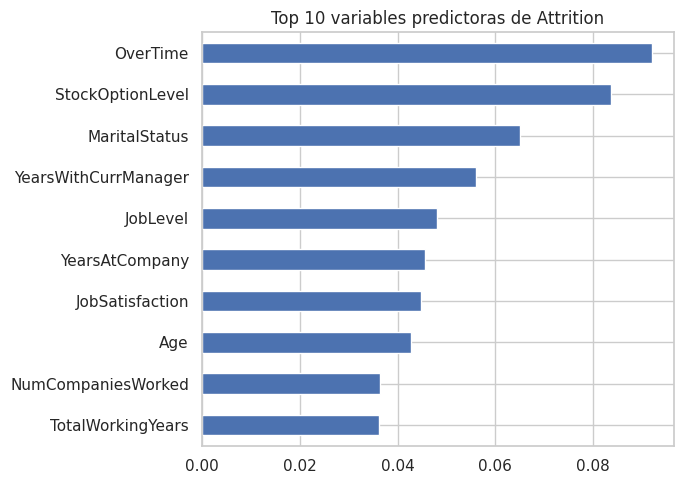

In [ ]:
plt.figure(figsize=(7,5))
importancias.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 variables predictoras de Attrition')
plt.tight_layout()
plt.show()

## 4. Modelos de Aprendizaje No Supervisado (Clustering)

Se aplican 3 tecnicas de clustering sobre las variables estandarizadas para segmentar a los empleados en grupos de riesgo, sin usar la etiqueta Attrition: **K-Means**, **Clustering Jerarquico (Agglomerative)** y **Gaussian Mixture Model (GMM)**.

In [ ]:
X_cluster = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
print(f"Varianza explicada PCA (2 comp): {pca.explained_variance_ratio_.sum():.2%}")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_cluster)
km_sil = silhouette_score(X_cluster, km_labels)

agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(X_cluster)
agglo_sil = silhouette_score(X_cluster, agglo_labels)

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_cluster)
gmm_sil = silhouette_score(X_cluster, gmm_labels)

df_cluster_res = pd.DataFrame({
    'Modelo': ['K-Means', 'Clustering Jerarquico', 'Gaussian Mixture'],
    'Silhouette Score': [km_sil, agglo_sil, gmm_sil]
})
df_cluster_res

Varianza explicada PCA (2 comp): 21.94%


,Modelo,Silhouette Score
0,K-Means,0.098873
1,Clustering Jerarquico,0.078582
2,Gaussian Mixture,0.035199


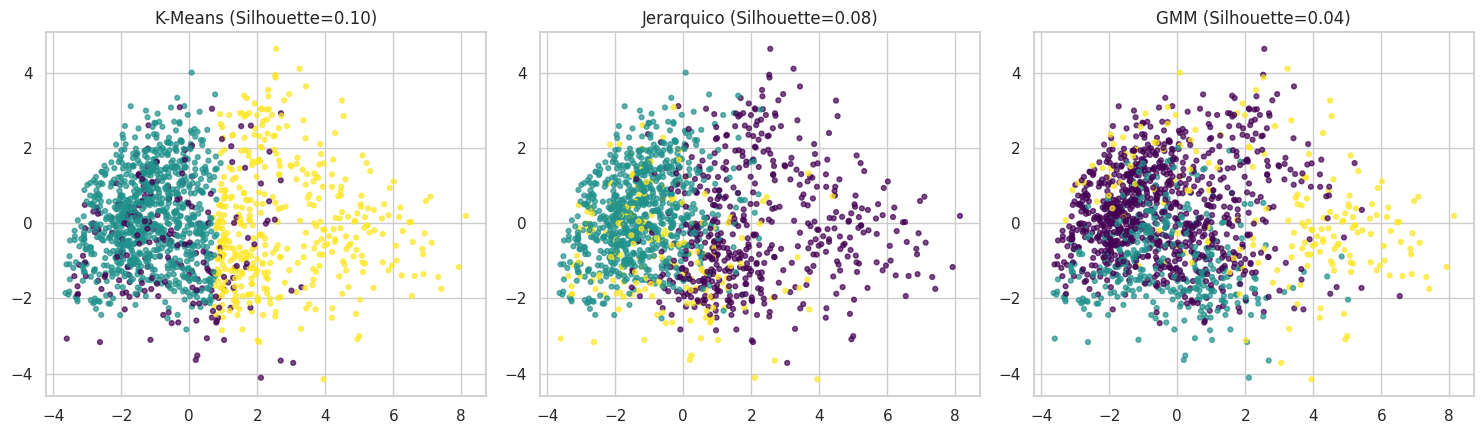

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (labels, nombre, sil) in zip(axes, [(km_labels,'K-Means',km_sil), (agglo_labels,'Jerarquico',agglo_sil), (gmm_labels,'GMM',gmm_sil)]):
    ax.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=12, alpha=0.7)
    ax.set_title(f'{nombre} (Silhouette={sil:.2f})')
plt.tight_layout()
plt.show()

### 4.1 Perfil de riesgo por cluster (K-Means)

In [ ]:
df_eda['Cluster_KMeans'] = km_labels
perfil_cluster = df_eda.groupby('Cluster_KMeans').agg(
    n_empleados=('Attrition_Flag', 'size'),
    tasa_attrition=('Attrition_Flag', 'mean'),
    ingreso_promedio=('MonthlyIncome', 'mean'),
    edad_promedio=('Age', 'mean'),
    pct_overtime=('OverTime', lambda s: (s == 'Yes').mean()),
    satisfaccion_prom=('JobSatisfaction', 'mean'),
).round(2)
perfil_cluster

,n_empleados,tasa_attrition,ingreso_promedio,edad_promedio,pct_overtime,satisfaccion_prom
Cluster_KMeans,,,,,,
0,202,0.18,5346.48,35.69,0.29,2.75
1,866,0.19,4428.60,34.21,0.28,2.73
2,402,0.09,11552.62,43.38,0.28,2.70


## 5. Descubrimiento de Patrones: Insight Cruzado

Se valida el ejemplo del caso: **Sueldo bajo + Horas Extra**.

OverTime           No       Yes
IngresoBajo                    
False        0.071017  0.186916
True         0.136961  0.430693


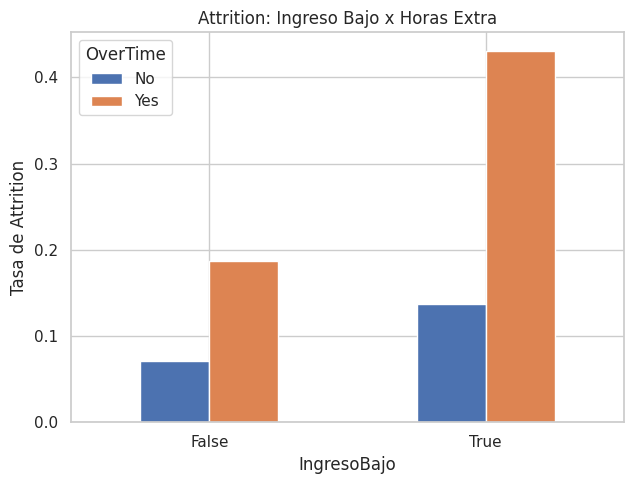

In [ ]:
df_eda['IngresoBajo'] = df_eda['MonthlyIncome'] < df_eda['MonthlyIncome'].median()
combo = df_eda.groupby(['IngresoBajo', 'OverTime'])['Attrition_Flag'].mean().unstack()
print(combo)

combo.plot(kind='bar', figsize=(6.5,5))
plt.title('Attrition: Ingreso Bajo x Horas Extra')
plt.ylabel('Tasa de Attrition')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Analisis Complementario: WorkLifeBalance, Top Performers y Ratio Ingreso/Experiencia

Se profundiza el analisis de H2 y H3 usando variables especificas del dataset que no se habian explorado, y se responde la pregunta del caso sobre si IBM esta perdiendo a sus Top Performers.

WorkLifeBalance vs Attrition (H3 especifica):
 WorkLifeBalance
1    0.312500
2    0.168605
3    0.142217
4    0.176471
Name: Attrition_Flag, dtype: float64 

JobLevel vs Attrition:
 JobLevel
1    0.263352
2    0.097378
3    0.146789
4    0.047170
5    0.072464
Name: Attrition_Flag, dtype: float64 

EnvironmentSatisfaction vs Attrition:
 EnvironmentSatisfaction
1    0.253521
2    0.149826
3    0.136865
4    0.134529
Name: Attrition_Flag, dtype: float64 

PerformanceRating vs Attrition (Top Performers):
 PerformanceRating
3    0.160772
4    0.163717
Name: Attrition_Flag, dtype: float64 

Ingreso por anio de experiencia, mediana por Attrition:
 Attrition
No     595.0
Yes    697.0
Name: IngresoPorAnioExp, dtype: float64


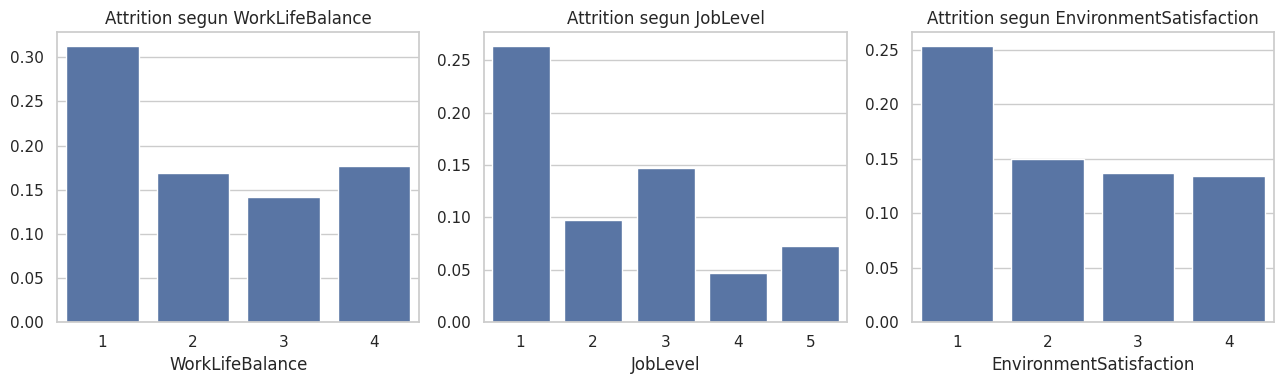

In [ ]:
wlb = df_eda.groupby('WorkLifeBalance')['Attrition_Flag'].mean()
jl = df_eda.groupby('JobLevel')['Attrition_Flag'].mean()
env = df_eda.groupby('EnvironmentSatisfaction')['Attrition_Flag'].mean()
perf = df_eda.groupby('PerformanceRating')['Attrition_Flag'].mean()

df_eda['IngresoPorAnioExp'] = df_eda['MonthlyIncome'] / df_eda['TotalWorkingYears'].replace(0, 1)
ratio_ingreso = df_eda.groupby('Attrition')['IngresoPorAnioExp'].median()

print('WorkLifeBalance vs Attrition (H3 especifica):\n', wlb, '\n')
print('JobLevel vs Attrition:\n', jl, '\n')
print('EnvironmentSatisfaction vs Attrition:\n', env, '\n')
print('PerformanceRating vs Attrition (Top Performers):\n', perf, '\n')
print('Ingreso por anio de experiencia, mediana por Attrition:\n', ratio_ingreso)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.barplot(x=wlb.index, y=wlb.values, ax=axes[0])
axes[0].set_title('Attrition segun WorkLifeBalance')
sns.barplot(x=jl.index, y=jl.values, ax=axes[1])
axes[1].set_title('Attrition segun JobLevel')
sns.barplot(x=env.index, y=env.values, ax=axes[2])
axes[2].set_title('Attrition segun EnvironmentSatisfaction')
plt.tight_layout()
plt.show()

### Hallazgo clave: Top Performers

La tasa de Attrition entre empleados con PerformanceRating alto (4 = Excellent) es de 16,37%, practicamente identica al 16,08% de quienes tienen rating 3. **Esto significa que IBM NO esta perdiendo desproporcionadamente a sus mejores empleados**: el desempenio formal no es una variable que discrimine bien la renuncia. El riesgo de fuga esta mucho mas ligado a OverTime, ingreso, JobLevel y WorkLifeBalance que al desempenio evaluado.

Tambien se confirma que el ingreso por anio de experiencia es mayor en quienes renuncian, lo cual en un primer vistazo parece contradecir H2, pero se explica porque el grupo que renuncia es mas joven (menos anios trabajados) y no porque gane objetivamente mejor: en terminos absolutos, el ingreso mensual de quienes renuncian sigue siendo menor.

## 6. Conclusiones

- El modelo con mejor **Recall** (metrica critica para IBM) es la **Regresion Logistica** (67.8%), lo que la hace la mas adecuada como sistema de alerta temprana, aunque Gradient Boosting ofrece el mejor equilibrio Precision/Recall y el mayor AUC-ROC.
- Las variables mas influyentes en la desercion son **OverTime, StockOptionLevel, MaritalStatus, YearsWithCurrManager y JobLevel**.
- Se confirma la hipotesis H1: quienes hacen horas extra desertan a una tasa notoriamente mayor.
- El cruce Sueldo Bajo + Horas Extra muestra la combinacion de mayor riesgo (cerca del 43% de attrition), validando el insight sugerido en el caso.
- El clustering identifica un grupo de empleados jovenes, con sueldos mas bajos y mayor tasa de desercion, que deberia priorizarse en las politicas de retencion.
